In [ ]:
# Wizualizacja pelnego potoku na jednym zdjeciu: kolejne etapy + wektor HOG + histogramy
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import sys

IMG_SIZE = (64, 64)
image_path = '../data/selected_signs/stop/00014_00000_00000.png'


def generate_full_pipeline_report(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Nie znaleziono obrazu: {img_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Etap 1: rozmycie + maska koloru + morfologia + wyciecie ROI
    img_blurred = cv2.GaussianBlur(img, (5, 5), 0)
    img_blurred_rgb = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2HSV)

    lo1, hi1 = np.array([0, 30, 40]), np.array([10, 255, 255])
    lo2, hi2 = np.array([160, 30, 40]), np.array([180, 255, 255])
    loy, hiy = np.array([20, 100, 100]), np.array([35, 255, 255])
    mask_combined = (cv2.inRange(hsv, lo1, hi1) |
                     cv2.inRange(hsv, lo2, hi2) |
                     cv2.inRange(hsv, loy, hiy))

    mask_clean = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))

    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        margin = int(0.05 * w)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img.shape[1], x + w + margin), min(img.shape[0], y + h + margin)
        roi = img[y1:y2, x1:x2]
    else:
        roi = img.copy()
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    # Etap 2: 64x64 -> skala szarosci -> HOG (visualize=True dla podgladu)
    gray = cv2.cvtColor(cv2.resize(roi, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)

    # Zapis pelnego wektora cech do pliku tekstowego (zalacznik do dokumentacji)
    with open('pelny_wektor_hog_zalacznik.txt', 'w') as f:
        f.write(f"Wektor cech HOG\n")
        f.write(f"Rozmiar obrazu wejsciowego: {IMG_SIZE}\n")
        f.write(f"Liczba cech: {len(features)}\n")
        f.write("=" * 70 + "\n\n")
        np.set_printoptions(threshold=sys.maxsize, linewidth=100, precision=4)
        f.write(np.array2string(features, separator=', '))

    # Wizualizacja 1: kolejne etapy potoku
    fig1, axes1 = plt.subplots(1, 7, figsize=(22, 4))
    fig1.suptitle('Pelny potok detekcji i ekstrakcji cech', fontsize=16, fontweight='bold', y=1.05)
    steps = [(img_rgb, "1. Oryginal", None), (img_blurred_rgb, "2. Rozmycie Gaussa", None),
             (mask_combined, "3. Maska HSV", 'gray'), (mask_clean, "4. Morfologia", 'gray'),
             (roi_rgb, "5. Wyciecie ROI", None), (gray, "6. 64x64 szarosc", 'gray'),
             (hog_image, "7. HOG", 'inferno')]
    for ax, (im, title, cmap) in zip(axes1, steps):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()

    # Wizualizacja 2: wartosci wektora HOG i ich rozklad
    fig2, axes2 = plt.subplots(2, 1, figsize=(15, 10))
    fig2.suptitle('Reprezentacja cech HOG', fontsize=16, fontweight='bold')
    axes2[0].bar(range(len(features)), features, color='royalblue', alpha=0.8)
    axes2[0].set_title(f'Wektor wejsciowy do SVM ({len(features)} cech)', fontsize=14)
    axes2[0].set_xlabel('Indeks cechy')
    axes2[0].set_ylabel('Sila gradientu')
    axes2[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes2[1].hist(features, bins=50, color='darkorange', edgecolor='black', alpha=0.8)
    axes2[1].set_title('Histogram rozkladu cech HOG', fontsize=14)
    axes2[1].set_xlabel('Wartosc cechy')
    axes2[1].set_ylabel('Czestotliwosc')
    axes2[1].grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Wizualizacja 3: histogram jasnosci pikseli - oryginal vs wejscie HOG
    fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
    fig3.suptitle('Wplyw przetwarzania na rozklad jasnosci pikseli', fontsize=16, fontweight='bold', y=1.05)
    axes3[0].imshow(original_gray, cmap='gray')
    axes3[0].set_title("Oryginal (szarosc)", fontsize=12)
    axes3[0].axis('off')
    axes3[1].hist(original_gray.ravel(), bins=256, range=[0, 256], color='gray', edgecolor='black', alpha=0.8)
    axes3[1].set_title('Histogram: oryginal', fontsize=12)
    axes3[1].set_xlabel('Jasnosc (0-255)')
    axes3[1].set_ylabel('Liczba pikseli')
    axes3[1].grid(axis='y', linestyle='--', alpha=0.5)
    axes3[2].imshow(gray, cmap='gray')
    axes3[2].set_title("ROI 64x64", fontsize=12)
    axes3[2].axis('off')
    axes3[3].hist(gray.ravel(), bins=256, range=[0, 256], color='black', edgecolor='gray', alpha=0.8)
    axes3[3].set_title('Histogram: wejscie HOG', fontsize=12)
    axes3[3].set_xlabel('Jasnosc (0-255)')
    axes3[3].set_ylabel('Liczba pikseli')
    axes3[3].grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


generate_full_pipeline_report(image_path)

In [ ]:
# Baseline: trening na zbiorze niezbalansowanym (potok HOG z ROI + SVM liniowy)
# Model finalny trenowany jest nizej na zbiorze zbalansowanym (db_balanced).
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

data_dir = '../data/selected_signs'
model_save_path = '../models/svm_model.pkl'
IMG_SIZE = (64, 64)

X, labels, rois_for_display = [], [], []
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    print(f"Przetwarzanie klasy: {class_name} ({len(os.listdir(class_path))} zdjec)")
    for img_name in os.listdir(class_path):
        img = cv2.imread(os.path.join(class_path, img_name))
        if img is None or img.size == 0:
            continue
        try:
            # Maska koloru HSV -> morfologia -> najwiekszy kontur -> wyciecie ROI
            hsv = cv2.cvtColor(cv2.GaussianBlur(img, (5, 5), 0), cv2.COLOR_BGR2HSV)
            lo1, hi1 = np.array([0, 30, 40]), np.array([10, 255, 255])
            lo2, hi2 = np.array([160, 30, 40]), np.array([180, 255, 255])
            loy, hiy = np.array([20, 100, 100]), np.array([35, 255, 255])
            mask = (cv2.inRange(hsv, lo1, hi1) |
                    cv2.inRange(hsv, lo2, hi2) |
                    cv2.inRange(hsv, loy, hiy))
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                bx, by, bw, bh = cv2.boundingRect(max(contours, key=cv2.contourArea))
                m = int(0.05 * bw)
                x1, y1 = max(0, bx - m), max(0, by - m)
                x2, y2 = min(img.shape[1], bx + bw + m), min(img.shape[0], by + bh + m)
                roi = img[y1:y2, x1:x2]
                if roi.size == 0:
                    roi = img.copy()
            else:
                roi = img.copy()

            gray = cv2.cvtColor(cv2.resize(roi, IMG_SIZE), cv2.COLOR_BGR2GRAY)
            features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
            X.append(features)
            labels.append(class_name)
            rois_for_display.append(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        except Exception:
            continue

X = np.array(X)
y = np.array(labels)
rois_for_display = np.array(rois_for_display, dtype=object)
print(f"Przetworzono {len(X)} zdjec.")

# Podzial 80/20 i trening
X_train, X_test, y_train, y_test, rois_train, rois_test = train_test_split(
    X, y, rois_for_display, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Ewaluacja
y_pred = svm_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))
joblib.dump(svm_model, model_save_path)
print(f"Model zapisany: {model_save_path}")

# Macierz pomylek
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')
plt.title('Macierz pomylek - SVM (HOG + ROI)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Galeria predykcji - po jednym przykladzie z kazdej klasy
unique_classes = np.unique(y_test)
fig2, axes2 = plt.subplots(1, len(unique_classes), figsize=(18, 4))
fig2.suptitle('Predykcje na zbiorze testowym', fontsize=16, fontweight='bold', y=1.1)
for i, cls in enumerate(unique_classes):
    idx = np.where(y_test == cls)[0][0]
    vec = X_test[idx].reshape(1, -1)
    prediction = svm_model.predict(vec)[0]
    confidence = np.max(svm_model.predict_proba(vec)) * 100
    color = 'green' if prediction == y_test[idx] else 'red'
    axes2[i].imshow(rois_test[idx])
    axes2[i].set_title(f"Predykcja: {prediction}\nPewnosc: {confidence:.1f}%\nPrawda: {y_test[idx]}",
                       fontsize=11, color=color, fontweight='bold')
    axes2[i].axis('off')
plt.tight_layout()
plt.show()

[INFO] 3900 zdjec z 5 klas (baza zbalansowana, z ROI).

[WYNIK] Accuracy: 91.54%

                        precision    recall  f1-score   support

Droga_z_pierwszenstwem       0.80      0.85      0.83       167
       Ograniczenie_30       0.95      0.92      0.93       163
                  Stop       0.99      0.96      0.98       157
   Ustap_pierwszenstwa       0.88      0.88      0.88       146
          Zakaz_wjazdu       0.97      0.97      0.97       147

              accuracy                           0.92       780
             macro avg       0.92      0.92      0.92       780
          weighted avg       0.92      0.92      0.92       780

[SUKCES] Model finalny zapisany: ../models/svm_model.pkl


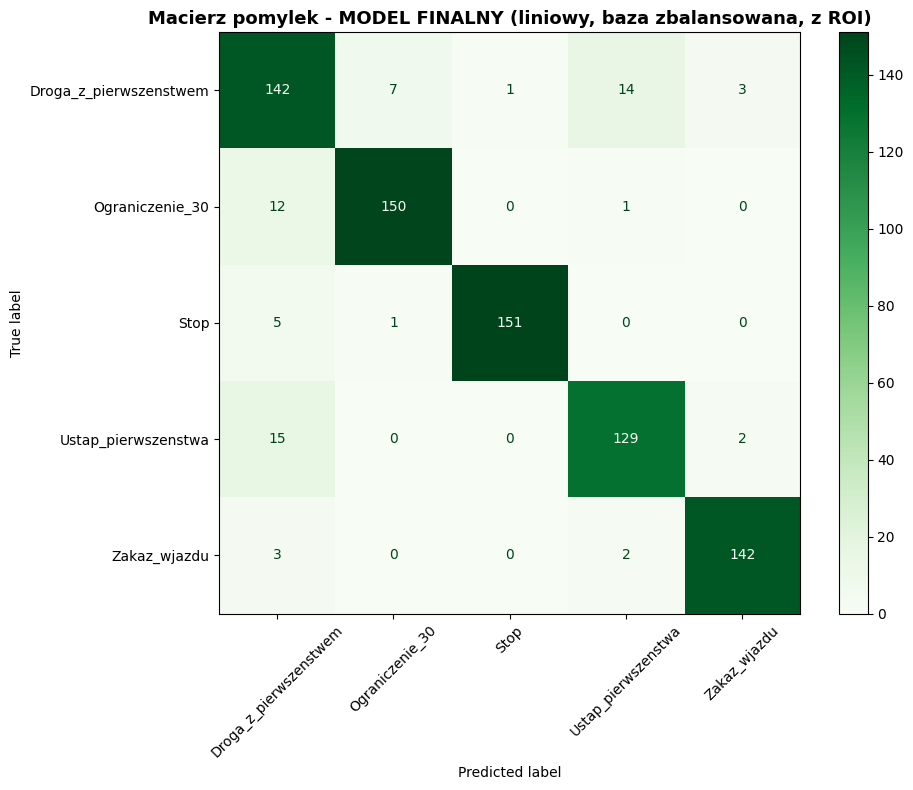

In [5]:
# ============================================================
# MODEL FINALNY: baza zbalansowana + ekstrakcja ROI + jadro liniowe
# Wnioski z eksperymentow (notebook 04):
#  - baza zbalansowana (780/klase) poprawia klasy mniej liczne -> uzywamy jej.
#  - Eksperyment E (bez ROI) dawal ~100% na holdoucie GTSRB, ale w PRAKTYCE
#    model gorzej generalizowal na realne wycinki z detekcji (poprawne znaki
#    ~37% pewnosci) - holdout != wdrozenie. Trening musi stosowac ten sam
#    preprocessing co inferencja, dlatego trenujemy Z ekstrakcja ROI.
#  - RBF dawal wyzsze accuracy na holdoucie, ale liniowy lepiej kalibruje
#    pewnosc na realnych zdjeciach (prog detekcji) -> deployujemy liniowy.
# Ta komorka NADPISUJE svm_model.pkl modelem finalnym.
# ============================================================
import os, cv2, numpy as np, joblib
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

DATA_DIR = '../data/db_balanced'
MODEL_SAVE_PATH = '../models/svm_model.pkl'
IMG_SIZE = (64, 64)


def extract_features(img):
    # ten sam potok ROI co w detekcji (notebook 03) - spojnosc trening/inferencja
    hsv = cv2.cvtColor(cv2.GaussianBlur(img, (5, 5), 0), cv2.COLOR_BGR2HSV)
    lo1, hi1 = np.array([0, 30, 40], np.uint8), np.array([10, 255, 255], np.uint8)
    lo2, hi2 = np.array([160, 30, 40], np.uint8), np.array([180, 255, 255], np.uint8)
    loy, hiy = np.array([20, 100, 100], np.uint8), np.array([35, 255, 255], np.uint8)
    mask = cv2.inRange(hsv, lo1, hi1) | cv2.inRange(hsv, lo2, hi2) | cv2.inRange(hsv, loy, hiy)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        bx, by, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        m = int(0.05 * bw)
        x1, y1 = max(0, bx - m), max(0, by - m)
        x2, y2 = min(img.shape[1], bx + bw + m), min(img.shape[0], by + bh + m)
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            roi = img.copy()
    else:
        roi = img.copy()
    gray = cv2.cvtColor(cv2.resize(roi, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')


X, y = [], []
for cls in sorted(os.listdir(DATA_DIR)):
    cp = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cp):
        continue
    for fn in os.listdir(cp):
        img = cv2.imread(os.path.join(cp, fn))
        if img is None or img.size == 0:
            continue
        try:
            X.append(extract_features(img)); y.append(cls)
        except Exception:
            continue
X, y = np.array(X), np.array(y)
print('[INFO] %d zdjec z %d klas (baza zbalansowana, z ROI).' % (len(X), len(np.unique(y))))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_tr, y_tr)

y_pred = svm_model.predict(X_te)
print('\n[WYNIK] Accuracy: %.2f%%\n' % (accuracy_score(y_te, y_pred) * 100))
print(classification_report(y_te, y_pred))

joblib.dump(svm_model, MODEL_SAVE_PATH)
print('[SUKCES] Model finalny zapisany:', MODEL_SAVE_PATH)

cm = confusion_matrix(y_te, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Greens', ax=ax, xticks_rotation=45, values_format='d')
plt.title('Macierz pomylek - MODEL FINALNY (liniowy, baza zbalansowana, z ROI)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [4]:
# ============================================================
# MODEL POROWNAWCZY: baza zbalansowana + BEZ ROI + jadro liniowe
# Sluzy TYLKO do porownania w dokumentacji (ROI vs bez ROI w detekcji).
# Rozni sie od modelu finalnego TYLKO brakiem ekstrakcji ROI - izoluje ten czynnik.
# Zapisuje do OSOBNEGO pliku, NIE nadpisuje modelu wdrozeniowego (svm_model.pkl).
#
# Aby przetestowac go w detekcji: w notebooku 03 zmien na gorze komorki
#   MODEL_PATH = '../models/svm_model_no_roi.pkl'
# i odpal detekcje; potem porownaj z modelem domyslnym (z ROI).
# ============================================================
import os, cv2, numpy as np, joblib
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

DATA_DIR = '../data/db_balanced'
MODEL_SAVE_PATH = '../models/svm_model_no_roi.pkl'
IMG_SIZE = (64, 64)


def extract_features_no_roi(img):
    # BEZ wyciecia ROI - caly obraz -> 64x64 -> HOG
    gray = cv2.cvtColor(cv2.resize(img, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')


X, y = [], []
for cls in sorted(os.listdir(DATA_DIR)):
    cp = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cp):
        continue
    for fn in os.listdir(cp):
        img = cv2.imread(os.path.join(cp, fn))
        if img is None or img.size == 0:
            continue
        try:
            X.append(extract_features_no_roi(img)); y.append(cls)
        except Exception:
            continue
X, y = np.array(X), np.array(y)
print('[INFO] %d zdjec z %d klas (baza zbalansowana, BEZ ROI).' % (len(X), len(np.unique(y))))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model_no_roi = SVC(kernel='linear', probability=True)
model_no_roi.fit(X_tr, y_tr)

y_pred = model_no_roi.predict(X_te)
print('\n[WYNIK] Accuracy (holdout GTSRB): %.2f%%\n' % (accuracy_score(y_te, y_pred) * 100))
print(classification_report(y_te, y_pred))

joblib.dump(model_no_roi, MODEL_SAVE_PATH)
print('[SUKCES] Model porownawczy (bez ROI) zapisany:', MODEL_SAVE_PATH)
print('Aby przetestowac w detekcji: w notebooku 03 ustaw MODEL_PATH =', repr(MODEL_SAVE_PATH))

[INFO] 3900 zdjec z 5 klas (baza zbalansowana, BEZ ROI).

[WYNIK] Accuracy (holdout GTSRB): 100.00%

                        precision    recall  f1-score   support

Droga_z_pierwszenstwem       1.00      1.00      1.00       167
       Ograniczenie_30       1.00      1.00      1.00       163
                  Stop       1.00      1.00      1.00       157
   Ustap_pierwszenstwa       1.00      1.00      1.00       146
          Zakaz_wjazdu       1.00      1.00      1.00       147

              accuracy                           1.00       780
             macro avg       1.00      1.00      1.00       780
          weighted avg       1.00      1.00      1.00       780

[SUKCES] Model porownawczy (bez ROI) zapisany: ../models/svm_model_no_roi.pkl
Aby przetestowac w detekcji: w notebooku 03 ustaw MODEL_PATH = '../models/svm_model_no_roi.pkl'
